# MNIST QNN - Computação Quântica Cega (BQC)

Este notebook demonstra como treinar um modelo híbrido de Rede Neural Quântica (QNN) usando o Qiskit e o PyTorch, aplicado a uma versão reduzida da base de dados MNIST (dígitos manuscritos).


**O que há de diferente aqui?**
Além do treinamento da rede neural, simulamos um ambiente de **Blind Quantum Computing (BQC)**. O processamento quântico é delegado de clientes (Alice) para um servidor (Bob) através de uma rede simulada (`quantumnet`). As condições dessa rede (como fidelidade e congestionamento) afetam diretamente o ruído introduzido no simulador quântico durante o aprendizado do modelo.

In [22]:
!pip install qiskit qiskit-aer qiskit-machine-learning scikit-learn torch matplotlib numpy


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator, BackendSampler
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import (
    Statevector, SparsePauliOp, state_fidelity
)

# Simulador e ruído
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Rede quântica
from quantumnet.components import Controller, Logger, Network

import os
import random
import numpy as np
import matplotlib.pyplot as plt

#PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#Qiskit

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import SparsePauliOp

#Simulador

from qiskit_aer import AerSimulator

#Métricas

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
accuracy_score, precision_score,
recall_score, f1_score,
confusion_matrix, classification_report
)

## 1. Controle de Aleatoriedade e Reprodutibilidade
Fixamos uma semente global (`SEED = 512`) para garantir que as simulações dos vetores de estado, inicialização dos pesos do PyTorch e divisões dos batches de dados sejam consistentes e reproduzíveis a cada execução.

In [24]:
SEED = 512
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

simulator = AerSimulator(method="statevector", seed_simulator=SEED)
try:
    from qiskit_algorithms.utils import algorithm_globals
    algorithm_globals.random_seed = SEED
except:
    pass

## 2. Configuração da Rede Quântica e Callbacks
Nesta etapa, instanciamos a topologia da nossa rede quântica simulada.


* **Topologia:** Usamos uma estrutura em grade (Grid) de 8x4.
* **Atores:** Vários nós clientes (IDs 13, 8, 2, 6, etc.) podem solicitar processamento ao servidor central (Nó 10).
* **Cenário BQC:** A função `enviar_circuito_por_epoca` simula o agendamento e envio do circuito quântico pela rede a cada passo do treinamento.
* **Ruído Dinâmico:** A função `gerenciar_ruido` calibra a probabilidade de erro de depolarização no simulador (`noise_p`) com base na estabilidade (fidelidade média) da rota da rede no momento da execução.

2026-01-14 13:38:28,272: Host 10 é o servidor, não receberá qubits.
2026-01-14 13:38:28,274: Host 13 inicializado com 0 qubits.
2026-01-14 13:38:28,275: Host 8 inicializado com 0 qubits.
2026-01-14 13:38:28,275: Host 2 inicializado com 0 qubits.
2026-01-14 13:38:28,276: Host 6 inicializado com 0 qubits.
2026-01-14 13:38:28,279: Host 0 inicializado com 0 qubits.
2026-01-14 13:38:28,280: Host 3 inicializado com 0 qubits.
2026-01-14 13:38:28,283: Host 11 inicializado com 0 qubits.
2026-01-14 13:38:28,286: Host 15 inicializado com 0 qubits.
2026-01-14 13:38:28,288: Host 1 inicializado com 0 qubits.
2026-01-14 13:38:28,289: Host 4 inicializado com 0 qubits.
2026-01-14 13:38:28,290: Host 5 inicializado com 0 qubits.
2026-01-14 13:38:28,292: Host 7 inicializado com 0 qubits.
2026-01-14 13:38:28,293: Host 9 inicializado com 0 qubits.
2026-01-14 13:38:28,294: Host 12 inicializado com 0 qubits.
2026-01-14 13:38:28,297: Host 14 inicializado com 0 qubits.
2026-01-14 13:38:28,302: Par EPR <quantumn

Hosts inicializados
Canais inicializados
Pares EPRs adicionados


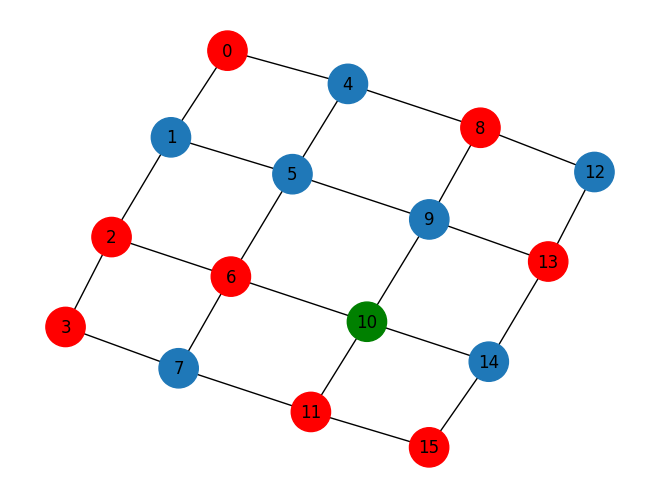

In [ ]:
SHOTS = 256
protocolo = "AC_BQC"

rede = Network()
controlador = Controller(rede)

clientes = [13, 8, 2, 6, 0, 3, 11, 15]
server = 10

# Topologia pronta (sem slices)
rede.set_ready_topology(
    'grade',
    8, 4, 4,
    clients=clientes,
    server=server
)

rede.draw()
Logger.activate(Logger)

def enviar_circuito_por_epoca(
    circuito,
    epoch,
    num_qubits,
    circuit_depth,
    rede,
    controlador,
    protocolo=protocolo
):
    print(f"[Epoch {epoch+1}] Enviando circuito — CENÁRIO 1")

    alice_id = random.choice([13, 8, 2, 6, 0, 3, 11, 15])
    bob_id = 10

    request = rede.generate_request(
        alice_id=alice_id,
        bob_id=bob_id,
        num_qubits=num_qubits,
        num_gates=circuit_depth,
        scenario=1
    )

    request["quantum_circuit"] = circuito
    request["protocol"] = protocolo

    controlador.receive_request(request)

    controlador.process_requests()
    controlador.send_scheduled_requests()

    print(
        f"[Epoch {epoch+1}] "
        f"Alice={alice_id} → Bob={bob_id} | Protocolo={protocolo}"
    )


def gerenciar_ruido(rede=None, num_qubits=4):
    """Versão adaptada do gerenciador de ruído para IRIS com BackendSampler"""
    
    noise_p = 0.01  
    
    if rede is None:
        print("[gerenciar_ruido_iris] Rede não disponível — mantendo ruído padrão.")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, noise_p
    
    try:
        fidelity = 0.8  
        
        if hasattr(rede, 'application_layer') and rede.application_layer:
            try:
                if hasattr(rede.application_layer, 'route_fidelities') and rede.application_layer.route_fidelities:
                    fidelities = rede.application_layer.route_fidelities
                    fidelity = sum(fidelities) / len(fidelities)
                    fidelity = max(0.6, min(0.99, fidelity))
                else:
                    fidelity = rede.application_layer.avg_fidelity_on_applicationlayer()
            except:
                fidelity = 0.8
        
        # 2) Mapeamento fidelidade → ruído (relação inversa)
        if fidelity >= 0.95:
            noise_p = 0.001 
        elif fidelity >= 0.90:
            noise_p = 0.004
        elif fidelity >= 0.85:
            noise_p = 0.005
        elif fidelity >= 0.80:
            noise_p = 0.008
        elif fidelity >= 0.75:
            noise_p = 0.01
        elif fidelity >= 0.70:
            noise_p = 0.02
        elif fidelity >= 0.65:
            noise_p = 0.04
        elif fidelity >= 0.60:
            noise_p = 0.08
        else:
            noise_p = 0.25 
        
        print(f" MAPEAMENTO IRIS: F={fidelity:.3f} → noise_p={noise_p:.3f}")
        
        dynamic_noise = NoiseModel()
        
        error_single = depolarizing_error(noise_p, 1)
        dynamic_noise.add_all_qubit_quantum_error(error_single, 
            ['id', 'x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz'])
        
        error_double = depolarizing_error(min(0.5, noise_p * 3), 2)
        dynamic_noise.add_all_qubit_quantum_error(error_double, ['cx', 'cz', 'swap'])
        
        simulator = AerSimulator(
            noise_model=dynamic_noise, 
            shots=SHOTS,
            method='density_matrix',
            seed_simulator=SEED
        )
        
        return simulator, noise_p
        
    except Exception as e:
        print(f"ERRO em gerenciar_ruido_iris: {e}")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, 0.01 


## 3. Funções Auxiliares de Visualização
Para entender o que o modelo está processando internamente, definimos funções para converter os vetores de estado quântico e amplitudes de volta para o formato de imagens ou matrizes visuais. Também incluímos um formatador para a Matriz de Confusão para a avaliação final.

In [ ]:

def show_figure1(pict, index=0):
    try:
        pict = np.asarray(pict, dtype=np.float64).ravel()
        if pict.max() > 0:
            pict = pict / pict.max()
        size = len(pict)
        dim = int(np.ceil(np.sqrt(size)))
        padded = np.zeros((dim * dim,))
        padded[:size] = pict
        plt.imshow(padded.reshape(dim, dim), cmap="Greys")
        plt.axis('off')

        plt.show()
    except Exception as e:
        print(f"Erro ao salvar figura {index}: {str(e)}")

def show_state_figure2(statevector, index=0):
    try:
        if hasattr(statevector, 'data'):
            statevector = statevector.data
        statevector = np.asarray(statevector, dtype=np.complex128)
        probs = np.abs(statevector) ** 2
        pict = np.abs(statevector[:784])

        plt.imshow(pict.reshape(28, 28), cmap="Greys")
        plt.axis("off")
        plt.show()

    except Exception as e:
        print(f"Erro ao processar estado {index}: {str(e)}")


def show_figure(pict: np.array, index=0, fidelity=None):
    plt.imshow(pict.reshape(28, 28), cmap="Greys")
    plt.axis('off')
    title = f"Imagem {index}"
    if fidelity is not None:
        title += f" - Fidelidade: {fidelity:.6f}"
    plt.title(f"Imagem {index}")
    plt.show()
    plt.close()

def show_state_figure(state, index=0, fidelity=None):
    state_np = np.array(state)
    pict = np.abs(state_np[:784])
    show_figure(pict, index=index, fidelity=fidelity)


def mostrar_matriz_confusao(y_true, y_pred, classes=None, title='Matriz de Confusão'):
    """
    Calcula e mostra a matriz de confusão formatada
    """
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{title}")
    print("=" * 30)
    
    if classes is None:
        classes = [f'Classe {i}' for i in range(len(cm))]
    
    header = "         " + " ".join(f"{cls:>8}" for cls in classes)
    print(header)
    print(" " * 9 + "-" * (len(classes) * 9))
    
    for i, row in enumerate(cm):
        row_str = f"{classes[i]:<8} |"
        for val in row:
            row_str += f" {val:>7}"
        print(row_str)
    
    return cm


## 4. Carregamento e Processamento dos Dados Quânticos (QASM)
Em vez de alimentar a QNN com pixels clássicos brutos, carregamos estados quânticos previamente preparados e salvos em arquivos `.qasm` (gerados a partir de amostras do MNIST).
1. Lemos e simulamos os circuitos para obter os vetores de estado (`Statevector`).
2. Extraímos **8 features** (amplitudes de probabilidade espaçadas) de cada imagem original. Isso comprime a informação e nos permite usar um circuito enxuto de apenas **8 qubits**.
3. Definimos os rótulos de forma binária (por exemplo, diferenciando duas classes específicas de dígitos).

In [ ]:

from qiskit.quantum_info import state_fidelity, Statevector
path = "base_test_mnist_784_f90/qasm/"

file_list = sorted(os.listdir(path))[:1000]
states = []
labels = []

for i, file_name in enumerate(file_list):
    try:
        full_path = os.path.join(path, file_name)
        with open(full_path) as f:
            qasm = f.read()
            qc = QuantumCircuit.from_qasm_str(qasm)
            qc.save_statevector()
            compiled = transpile(qc, simulator)
            job = simulator.run(compiled)
            result = job.result()
            state = result.data(0)['statevector']
            state_sv = Statevector(state)
            reference_state = np.zeros(state.dim, dtype=complex)
            reference_state[0] = 1.0
            fidelity = state_fidelity(state_sv, reference_state)

            print(f"Fidelidade da imagem {i}: {fidelity:.6f}")
            features = np.abs(state)**2
            features = features[np.linspace(0, len(features)-1, 8, dtype=int)]
            states.append(features)
            labels.append(i % 2)

    except Exception as e:
        print(f"Erro ao processar {file_name}: {str(e)}")



Fidelidade da imagem 0: 0.000001
Fidelidade da imagem 1: 0.000989
Fidelidade da imagem 2: 0.000132
Fidelidade da imagem 3: 0.000000
Fidelidade da imagem 4: 0.000023
Fidelidade da imagem 5: 0.000021
Fidelidade da imagem 6: 0.000023
Fidelidade da imagem 7: 0.000001
Fidelidade da imagem 8: 0.000108
Fidelidade da imagem 9: 0.000383
Fidelidade da imagem 10: 0.000000
Fidelidade da imagem 11: 0.000008
Fidelidade da imagem 12: 0.000052
Fidelidade da imagem 13: 0.000000
Fidelidade da imagem 14: 0.000007
Fidelidade da imagem 15: 0.000078
Fidelidade da imagem 16: 0.000004
Fidelidade da imagem 17: 0.000013
Fidelidade da imagem 18: 0.000022
Fidelidade da imagem 19: 0.000006
Fidelidade da imagem 20: 0.000067
Fidelidade da imagem 21: 0.000002
Fidelidade da imagem 22: 0.000014
Fidelidade da imagem 23: 0.000001
Fidelidade da imagem 24: 0.000016
Fidelidade da imagem 25: 0.000012
Fidelidade da imagem 26: 0.000071
Fidelidade da imagem 27: 0.000013
Fidelidade da imagem 28: 0.000004
Fidelidade da imagem 29:

## 5. Divisão e Tensores (PyTorch)
Normalizamos as matrizes de características para evitar a explosão de gradientes e dividimos o dataset em 70% para treino e 30% para teste, mantendo a proporção correta das classes com o parâmetro `stratify`. Por fim, os arrays são convertidos em tensores nativos do PyTorch.

In [31]:
X = np.array(states, dtype=np.float32)
y = np.array(labels, dtype=np.int64)

print("Diferença entre amostras:",
      np.linalg.norm(X[0] - X[1]),
      np.linalg.norm(X[0] - X[10]))

X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.3,
random_state=SEED,
stratify=y
)

X_train_tensor = torch.tensor(X_train)
X_test_tensor = torch.tensor(X_test)
y_train_tensor = torch.tensor(y_train)
y_test_tensor = torch.tensor(y_test)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Diferença entre amostras: 0.0058823926 0.019416621
Treino: (700, 8) | Teste: (300, 8)


## 6. Construção do Circuito Quântico 
Criamos o núcleo da nossa QNN combinando dois blocos fundamentais:


1. **Feature Map (`PauliFeatureMap`):** Responsável por codificar os nossos dados clássicos (as 8 features extraídas) no estado quântico utilizando rotações em Z e X.
2. **Ansatz (`RealAmplitudes`):** O nosso circuito heurístico de aprendizado. Ele contém portas parametrizadas cujos ângulos ($\theta$) serão continuamente ajustados pelo otimizador clássico para aprender o padrão dos dígitos.

In [32]:
num_qubits = X.shape[1]
num_classes = 2

from qiskit.circuit.library import PauliFeatureMap

feature_map = PauliFeatureMap(
    num_qubits,
    paulis=['Z', 'X'],
    reps=1,
    entanglement='linear'
)

ansatz = RealAmplitudes(
    num_qubits,
    reps=1,
    entanglement='linear'
)


qc_qnn = QuantumCircuit(num_qubits)
qc_qnn.compose(feature_map, inplace=True)
qc_qnn.compose(ansatz, inplace=True)

In [33]:
observables = [
    SparsePauliOp.from_list([("ZIIIIIII", 1.0)]),
    SparsePauliOp.from_list([("IZIIIIII", 1.0)]),
    SparsePauliOp.from_list([("IIZIIIII", 1.0)]),
    SparsePauliOp.from_list([("IIIZIIII", 1.0)]),
    SparsePauliOp.from_list([("IIIIZIII", 1.0)]),
    SparsePauliOp.from_list([("IIIIIZII", 1.0)]),
    SparsePauliOp.from_list([("IIIIIIZI", 1.0)]),
    SparsePauliOp.from_list([("IIIIIIIZ", 1.0)])
]


In [34]:
def gerenciar_ruido_mnisq(rede, num_qubits):
    f = rede.application_layer.avg_fidelity_on_applicationlayer()
    f = max(0.6, min(0.99, f))

    if f > 0.9:
        noise_p = 0.002
    elif f > 0.8:
        noise_p = 0.01
    elif f > 0.7:
        noise_p = 0.03
    else:
        noise_p = 0.08

    noise = NoiseModel()
    noise.add_all_qubit_quantum_error(
        depolarizing_error(noise_p, 1),
        ['id','x','y','z','h','rx','ry','rz']
    )
    noise.add_all_qubit_quantum_error(
        depolarizing_error(noise_p*2, 2),
        ['cx','cz']
    )

    sim = AerSimulator(
        noise_model=noise,
        shots=SHOTS,
        method="density_matrix",
        seed_simulator=SEED
    )

    print(f"Ruído atualizado: {noise_p:.4f}")
    return sim

## 7. Modelo Híbrido (EstimatorQNN + PyTorch)
Primeiro, definimos um conjunto de **Observáveis** (medições usando portas Pauli-Z em qubits individuais). O `Estimator` usará isso para extrair o valor de expectativa final do circuito.

A "mágica" híbrida acontece com o `TorchConnector`. Ele encapsula o nosso `EstimatorQNN` do Qiskit, transformando-o em uma camada padrão (`nn.Module`) do PyTorch. Isso permite que a camada quântica alimente uma camada linear clássica (`nn.Linear`) que tomará a decisão final entre as 2 classes.

In [35]:
estimator = Estimator(options={"backend": simulator})

qnn = EstimatorQNN(
circuit=qc_qnn,
estimator=estimator,
observables=observables,
input_params=feature_map.parameters,
weight_params=ansatz.parameters
)

initial_weights = 0.01 * np.random.randn(qnn.num_weights)

model = nn.Sequential(
    TorchConnector(qnn, initial_weights=initial_weights),
    nn.Linear(len(observables), num_classes)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_10356\910065463.py:1: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator(options={"backend": simulator})
C:\Users\Dreysv\AppData\Local\Temp\ipykernel_10356\910065463.py:3: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = EstimatorQNN(


## 8. Loop de Treinamento e Feedback Dinâmico da Rede
Durante o treinamento, realizamos a simulação do sistema distribuído:
1. **Ruído Adaptativo:** O nível de erro do backend (`Estimator`) é recalculado pela função de ruído com base no estado da rede.
2. **Otimização:** O PyTorch realiza o *forward pass*, calcula o erro (`CrossEntropyLoss`) e aplica o *backpropagation*, ajustando tanto os pesos clássicos quanto os ângulos do circuito quântico (Adam).
3. **Feedback Ambiental:** A acurácia atingida no conjunto de testes influencia a fidelidade da rede simulada para a próxima época. Se o modelo está aprendendo bem, a rede estabiliza; se não, a fidelidade cai.
4. **Tráfego BQC:** Ao final da época, empacotamos e enviamos o circuito pela infraestrutura para contabilizar o consumo de EPRs.

In [ ]:
num_epochs = 5
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

train_accs = []
test_accs = []
train_losses = []
epoch_loss = 0.0


for epoch in range(num_epochs):
    print(f"\n=== ÉPOCA {epoch+1}/{num_epochs} ===")

    simulator_updated, noise_used = gerenciar_ruido(rede, num_qubits)

    estimator_updated = Estimator(
        options={"backend": simulator_updated}
    )

    model[0].neural_network.estimator = estimator_updated

    print(f"Ruído aplicado: {noise_used:.4f}")

    model.train()
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        out = model(xb)
        loss = criterion(out, yb)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        pred = out.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    train_acc = correct / total
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        test_out = model(X_test_tensor)
        test_pred = test_out.argmax(dim=1)
        test_acc = (test_pred == y_test_tensor).sum().item() / y_test_tensor.size(0)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Treino: {train_acc:.3f} | Teste: {test_acc:.3f}")

    f_ant = rede.application_layer.avg_fidelity_on_applicationlayer()
    f_target = test_acc

    nova_fidelidade = 0.5 * f_ant + 0.5 * f_target

    rede.application_layer.route_fidelities = [
        nova_fidelidade for _ in rede.application_layer.route_fidelities
    ]

    print(f"[Feedback] Acurácia={test_acc:.3f} → Fidelidade={nova_fidelidade:.3f}")

    enviar_circuito_por_epoca(
    circuito=qc,
    epoch=epoch,
    num_qubits=num_qubits,
    circuit_depth=qc.depth(),
    rede=rede,
    controlador=controlador,
    protocolo=protocolo
    )



2026-01-14 13:40:26,468: Nenhuma fidelidade foi registrada na camada de aplicação.



=== ÉPOCA 1/5 ===
 MAPEAMENTO IRIS: F=0.000 → noise_p=0.250
Ruído aplicado: 0.2500


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_10356\2491913491.py:21: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator_updated = Estimator(
2026-01-14 13:52:27,093: Nenhuma fidelidade foi registrada na camada de aplicação.


Treino: 0.500 | Teste: 0.500
[Feedback] Acurácia=0.500 → Fidelidade=0.354
[Epoch 1] Enviando circuito — CENÁRIO 1
                                                               ┌───┐           »
q_0: ─────■─────────────────────────■────────■─────────────────┤ X ├─■─────────»
          │             ┌───┐┌───┐  │  ┌───┐ │            ┌───┐└─┬─┘ │         »
q_1: ─────■───────────■─┤ X ├┤ X ├──┼──┤ Z ├─┼────────────┤ X ├──┼───┼─────────»
        ┌───┐┌───┐    │ └───┘└───┘  │  └───┘ │            └─┬─┘  │   │         »
q_2: ─X─┤ Y ├┤ Z ├────┼─────────────┼────────┼───■──────X───┼────┼───┼─────────»
      │ └───┘└───┘    │             │  ┌───┐ │   │      │   │    │   │         »
q_3: ─┼───────────────┼────────■────┼──┤ H ├─┼───■───■──┼───■────┼───■─────────»
      │ ┌───┐┌───┐    │ ┌───┐  │    │  └───┘ │ ┌───┐ │  │ ┌───┐  │     ┌───┐   »
q_4: ─┼─┤ S ├┤ Y ├─X──┼─┤ X ├──┼────┼────────■─┤ T ├─┼──┼─┤ X ├──┼───■─┤ Z ├───»
      │ └───┘└───┘ │  │ └───┘  │    │          └───┘ │  │ └─┬─┘  │   │ ├───┤

2026-01-14 13:52:27,641: Circuito aleatório gerado com 8 qubits e 174 portas. Instruções sobre o circuito.
2026-01-14 13:52:27,641: Instrução: {'operation': 'swap', 'qubits': [2, 5]}
2026-01-14 13:52:27,642: Instrução: {'operation': 's', 'qubits': [4]}
2026-01-14 13:52:27,642: Instrução: {'operation': 'cz', 'qubits': [0, 1]}
2026-01-14 13:52:27,643: Instrução: {'operation': 'y', 'qubits': [4]}
2026-01-14 13:52:27,643: Instrução: {'operation': 'y', 'qubits': [2]}
2026-01-14 13:52:27,644: Instrução: {'operation': 'z', 'qubits': [2]}
2026-01-14 13:52:27,644: Instrução: {'operation': 'y', 'qubits': [7]}
2026-01-14 13:52:27,644: Instrução: {'operation': 'swap', 'qubits': [4, 6]}
2026-01-14 13:52:27,645: Instrução: {'operation': 'y', 'qubits': [7]}
2026-01-14 13:52:27,645: Instrução: {'operation': 'x', 'qubits': [4]}
2026-01-14 13:52:27,645: Instrução: {'operation': 'cz', 'qubits': [7, 1]}
2026-01-14 13:52:27,646: Instrução: {'operation': 'x', 'qubits': [1]}
2026-01-14 13:52:27,646: Instruçã

...

Treino: 0.539 | Teste: 0.507
[Feedback] Acurácia=0.507 → Fidelidade=0.778
[Epoch 5] Enviando circuito — CENÁRIO 1
     ┌───┐                                                                    »
q_0: ┤ Y ├───────────────────────■───X───■──────────────────────────────■─────»
     └───┘                       │   │   │     ┌───┐┌───┐               │     »
q_1: ──■───────────X─────────────┼───┼───┼───X─┤ H ├┤ T ├──■───X────────┼───■─»
       │           │             │   │ ┌─┴─┐ │ └───┘└───┘  │   │ ┌───┐  │   │ »
q_2: ──┼───■───────┼─────────────┼───┼─┤ X ├─X─────────────■───X─┤ Y ├──┼───┼─»
       │   │ ┌───┐ │ ┌───┐       │   │ └───┘                     └───┘  │   │ »
q_3: ──■───┼─┤ T ├─┼─┤ T ├───────┼───┼────────────────X────────X────────┼───┼─»
           │ └───┘ │ ├───┤┌───┐┌─┴─┐ │                │  ┌───┐ │ ┌───┐  │   │ »
q_4: ──────┼───X───┼─┤ T ├┤ X ├┤ X ├─X───X───X────────┼──┤ X ├─┼─┤ T ├──┼───┼─»
     ┌───┐ │   │   │ ├───┤└───┘└───┘     │   │ ┌───┐  │  └─┬─┘ │ └───┘  │   │ »
q_5: ┤

2026-01-14 14:41:37,163: Circuito aleatório gerado com 8 qubits e 174 portas. Instruções sobre o circuito.
2026-01-14 14:41:37,164: Instrução: {'operation': 'cz', 'qubits': [1, 3]}
2026-01-14 14:41:37,164: Instrução: {'operation': 'y', 'qubits': [7]}
2026-01-14 14:41:37,165: Instrução: {'operation': 't', 'qubits': [3]}
2026-01-14 14:41:37,165: Instrução: {'operation': 'swap', 'qubits': [4, 7]}
2026-01-14 14:41:37,166: Instrução: {'operation': 't', 'qubits': [4]}
2026-01-14 14:41:37,166: Instrução: {'operation': 'y', 'qubits': [0]}
2026-01-14 14:41:37,167: Instrução: {'operation': 'y', 'qubits': [5]}
2026-01-14 14:41:37,167: Instrução: {'operation': 'swap', 'qubits': [1, 5]}
2026-01-14 14:41:37,167: Instrução: {'operation': 't', 'qubits': [5]}
2026-01-14 14:41:37,169: Instrução: {'operation': 'cz', 'qubits': [2, 6]}
2026-01-14 14:41:37,170: Instrução: {'operation': 'x', 'qubits': [4]}
2026-01-14 14:41:37,170: Instrução: {'operation': 'cx', 'qubits': [0, 4]}
2026-01-14 14:41:37,171: Inst

Tempo de Operação: 60


2026-01-14 14:41:37,557: Taxa de sucesso do protocolo: 100.00% (8/8 qubits)
2026-01-14 14:41:37,558: Qubit 877 devolvido para o cliente - Estado: 1, Fase: -1
2026-01-14 14:41:37,559: Qubit 207 devolvido para o cliente - Estado: 0, Fase: 1
2026-01-14 14:41:37,559: Qubit 708 devolvido para o cliente - Estado: 1, Fase: -1
2026-01-14 14:41:37,560: Qubit 210 devolvido para o cliente - Estado: 1, Fase: 1
2026-01-14 14:41:37,561: Qubit 294 devolvido para o cliente - Estado: 1, Fase: -1
2026-01-14 14:41:37,561: Qubit 842 devolvido para o cliente - Estado: 0, Fase: 1
2026-01-14 14:41:37,562: Qubit 313 devolvido para o cliente - Estado: 0, Fase: 1
2026-01-14 14:41:37,562: Qubit 184 devolvido para o cliente - Estado: 1, Fase: 1
2026-01-14 14:41:37,563: Cliente aplicou a decodificação Clifford no qubit 877.
2026-01-14 14:41:37,563: Cliente aplicou a decodificação Clifford no qubit 207.
2026-01-14 14:41:37,563: Cliente aplicou a decodificação Clifford no qubit 708.
2026-01-14 14:41:37,564: Cliente 

Pares EPRs adicionados
Hosts inicializados
[Epoch 5] Alice=0 → Bob=10 | Protocolo=AC_BQC


## 9. Avaliação Final e Diagnósticos
Testamos a capacidade de generalização do modelo contra o conjunto de teste e extraímos:
* Relatório completo e Matriz de Confusão.
* **Métricas da infraestrutura quântica:** O número total de pares emaranhados (EPRs) consumidos e a fidelidade média final da transmissão.
* Gráficos comparativos de evolução da Loss/Acurácia e das previsões contra os rótulos reais.

In [37]:
print("\nCALCULANDO MÉTRICAS MULTICLASSE...")

model.eval()
with torch.no_grad():

    logits = model(X_test_tensor)
    logits = logits * 3.0
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()


    # Classe prevista
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()

    print("\n" + "="*50)
    print("MATRIZ DE CONFUSÃO")
    print("="*50)

    num_classes = len(np.unique(y_true))
    class_names = [f"Classe {i}" for i in range(num_classes)]

    cm = confusion_matrix(y_true, y_pred)

    mostrar_matriz_confusao(
        y_true,
        y_pred,
        classes=class_names,
        title="Matriz de Confusão - QNN Multiclasse"
    )

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print("\nMÉTRICAS FINAIS:")
    print(f"Acurácia : {accuracy:.4f}")
    print(f"Precisão : {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
    print(classification_report(y_true, y_pred, target_names=class_names))



CALCULANDO MÉTRICAS MULTICLASSE...

MATRIZ DE CONFUSÃO

Matriz de Confusão - QNN Multiclasse
         Classe 0 Classe 1
         ------------------
Classe 0 |     108      42
Classe 1 |     106      44

MÉTRICAS FINAIS:
Acurácia : 0.5067
Precisão : 0.5082
Recall   : 0.5067
F1 Score : 0.4831

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

    Classe 0       0.50      0.72      0.59       150
    Classe 1       0.51      0.29      0.37       150

    accuracy                           0.51       300
   macro avg       0.51      0.51      0.48       300
weighted avg       0.51      0.51      0.48       300



In [38]:
media_fidelidade = rede.application_layer.avg_fidelity_on_applicationlayer()
num_eprs = rede.get_total_useds_eprs()

print("\nMÉTRICAS DA REDE QUÂNTICA:")
print(f"Fidelidade média das rotas: {media_fidelidade:.4f}")
print(f"EPRs usados: {num_eprs}")

print("\nFidelidades por rota:")
rede.application_layer.print_route_fidelities()


2026-01-14 14:41:48,287: A média das fidelidades das rotas é: 0.8224
2026-01-14 14:41:48,288: Eprs usados na camada LinkLayer: 0
2026-01-14 14:41:48,289: Eprs usados na camada NetworkLayer: 0
2026-01-14 14:41:48,290: Eprs usados na camada ApplicationLayer: 192



MÉTRICAS DA REDE QUÂNTICA:
Fidelidade média das rotas: 0.8224
EPRs usados: 192

Fidelidades por rota:
Fidelidades das rotas utilizadas:
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
0.7780
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000
1.0000


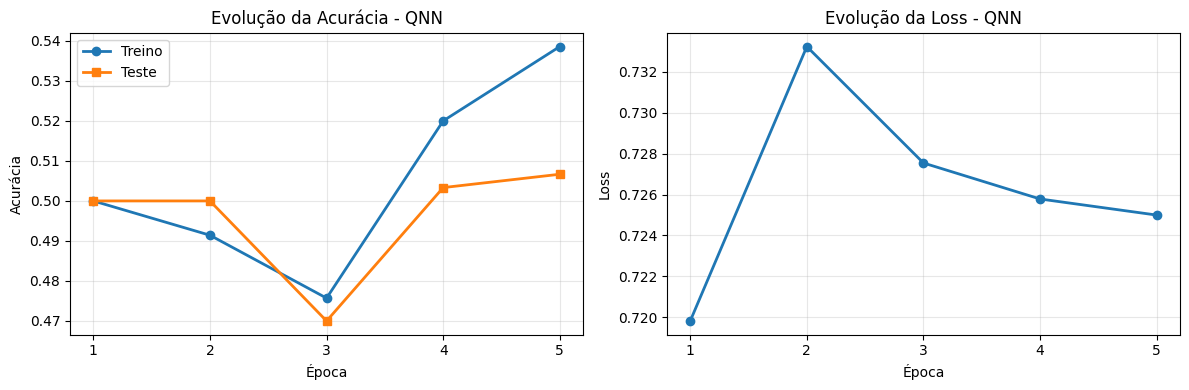

In [ ]:

epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_accs, 'o-', label='Treino', linewidth=2)
ax1.plot(epochs, test_accs, 's-', label='Teste', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.set_title('Evolução da Acurácia - QNN')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs)

ax2.plot(epochs, train_losses, 'o-', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.set_title('Evolução da Loss - QNN')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs)

plt.tight_layout()
plt.show()


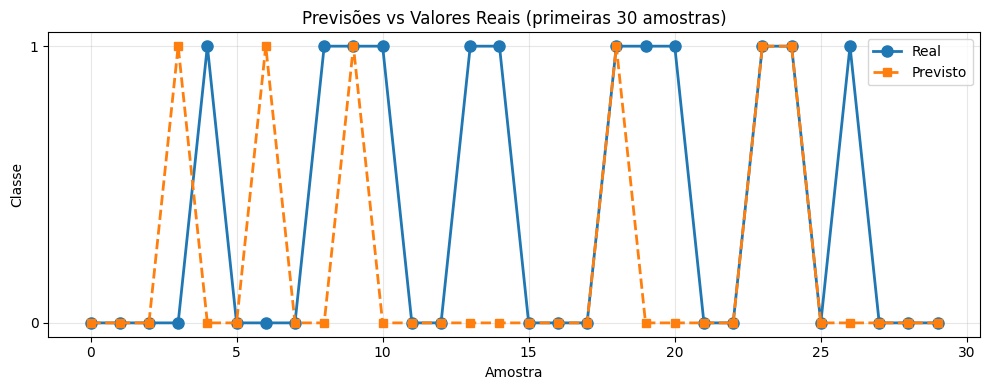

In [41]:
plt.figure(figsize=(10, 4))

n_samples = min(30, len(y_true))

plt.plot(y_true[:n_samples], 'o-', label='Real', markersize=8, linewidth=2)
plt.plot(y_pred[:n_samples], 's--', label='Previsto', markersize=6, linewidth=2)

plt.xlabel('Amostra')
plt.ylabel('Classe')
plt.title(f'Previsões vs Valores Reais (primeiras {n_samples} amostras)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 1])

plt.tight_layout()
plt.show()


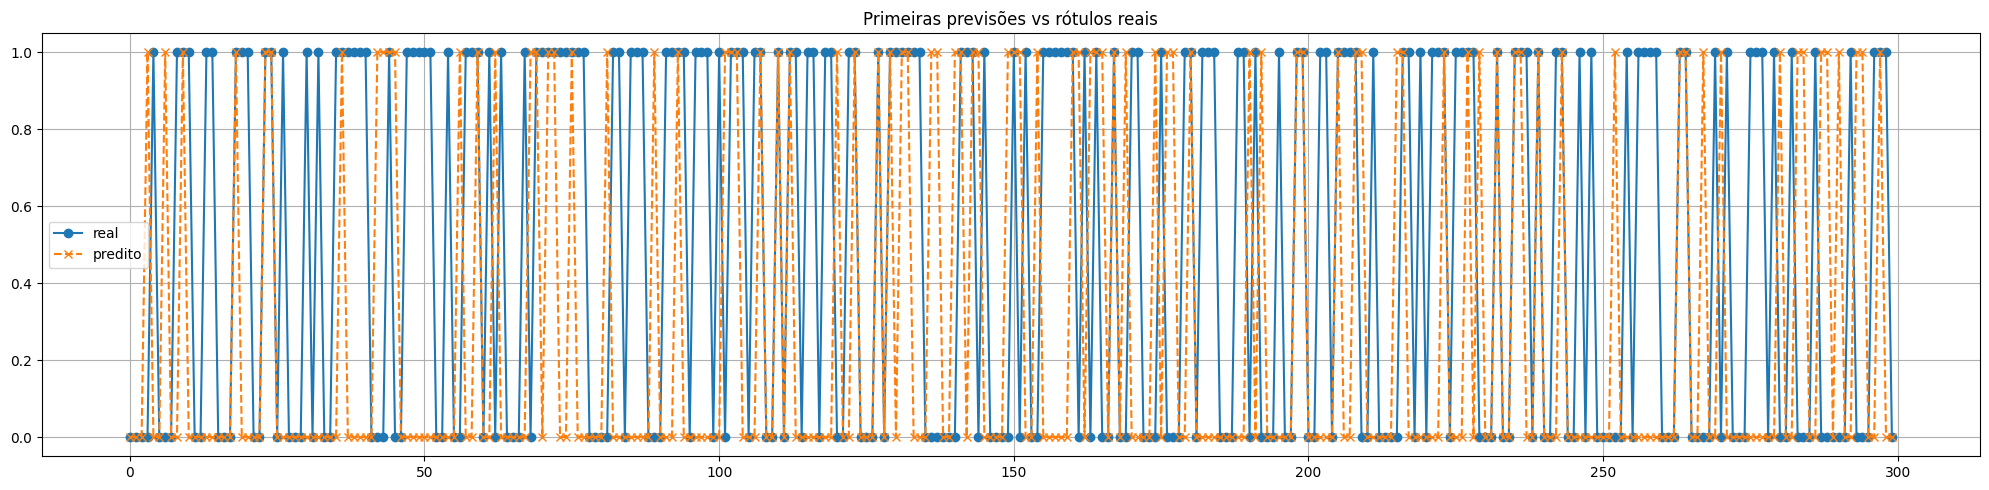

In [42]:
plt.figure(figsize=(20,5))
plt.title('Primeiras previsões vs rótulos reais')
plt.plot(y_true, marker='o', label='real')
plt.plot(y_pred, marker='x', linestyle='--', label='predito')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()